# Build Your First Neural Network

Can four flower measurements help predict a species? We will build a small PyTorch classifier from start to finish: split the examples, scale measurements, train, choose a checkpoint, compare against a simpler model, and reuse the finished predictor.

Run from a fresh kernel using the [README setup](README.md). PyTorch, NumPy, Matplotlib, and scikit-learn are required. The Iris dataset is bundled with scikit-learn, so running needs no dataset download, credentials, or GPU. The [notes](12_Build_Your_First_Neural_Network_Notes.ipynb) explain the project independently.

This small benchmark is a learning project, not a reliable identification service for arbitrary plants. Its class list contains only three iris species.

## Start with the problem this lesson solves

We want to identify an Iris flower's species from four measured lengths and widths. The inputs are measurements; the target is one of three species. The ANN learns combinations of measurements that help distinguish classes, then converts those combinations into three competing scores.

A useful project includes more than the network: feature order, training-only preprocessing, a baseline, separate evaluation data, and a way to reuse the same prediction recipe. Each part prevents a different way of obtaining a misleading or unusable result.

## Follow one miniature flower classifier completely

To make every multiplication visible, use a **hand-chosen 4 → 2 → 3 miniature**, smaller than the companion's trained 4 → 8 → 3 model. Its numbers are teaching values, not fitted Iris statistics or predictions.

**Scale the measurements.** In the order sepal length, sepal width, petal length, petal width, take raw measurements $[6,3,3,2]$, illustrative training means $[5,3,4,1]$, and scales $[1,0.5,1,0.5]$. Subtract the corresponding mean and divide by the corresponding scale:

$$x=[(6-5)/1,(3-3)/0.5,(3-4)/1,(2-1)/0.5]=[1,0,-1,2].$$

A value of two in the last position means two training standard deviations above its mean, not two centimeters. Fitting this transformation on test flowers would let evaluation data influence the recipe.

**Compute both hidden neurons.** Choose weight rows $[1,0,-1,0]$ and $[0,1,0,-1]$, with biases zero and one:

$$z_1=1(1)+0(0)+(-1)(-1)+2(0)+0=2,$$
$$z_2=1(0)+0(1)+(-1)(0)+2(-1)+1=-1.$$

Apply ReLU to obtain $h=[2,0]$.

**Compute all class scores.** Choose output weight rows $[1,0]$, $[0,1]$, and $[-1,1]$, with all output biases zero. The three logits are $[2(1)+0(0),2(0)+0(1),2(-1)+0(1)]=[2,0,-2]$.

**Turn scores into probabilities.** For stable softmax, subtract the maximum two first: $[0,-2,-4]$. Exponentials are approximately $[1,0.135335,0.018316]$, with sum $1.153651$. Divide to obtain $[0.866813,0.117310,0.015876]$. The probabilities sum to one, and the largest picks class zero. Class names must come from the stored label mapping.

**Use the known label to teach.** If this example's true class is one, the prediction is wrong and loss is $-\ln(0.117310)\approx2.142932$. Logit gradients are probability minus one-hot target: $[0.866813,-0.882690,0.015876]$. They encourage lower wrong-class scores and a higher true-class score.

For a simple bias-only illustration, freeze all weights and adjust only class one's output bias with rate $0.1$. Its bias changes from zero to $0-0.1(-0.882690)=0.088269$, so the logits become $[2,0.088269,-2]$. Class one's probability increases to about $0.1268$ and loss drops to about $2.0654$. Actual ANN training updates all trainable layers; this restricted step isolates how a classification error guides one parameter.

## Why the complete project can help with new flowers

The hidden layer creates learned combinations of measurements; the output layer uses them as evidence for species. Training makes the parameters useful, while held-out evaluation checks whether that usefulness extends beyond the training flowers. A logistic-regression baseline tests whether the nonlinear network adds value on this small dataset.

Inference repeats feature ordering, stored scaling, forward computation, and class mapping. It does not refit the scaler, access a target label, or update the model. Saving only the weights loses part of the meaning of the input and output numbers, so the companion saves the prediction recipe too. Similar test accuracy between ANN and baseline is a valid result, not a reason to hide the baseline.

## Connect the explanation to the code

`prepare` applies means and scales fitted on training rows. `nn.Linear(4, 8)` learns eight combinations of the four measurements; ReLU transforms them; `nn.Linear(8, 3)` produces class logits. `CrossEntropyLoss` teaches from integer class IDs. `argmax` selects a class, while `softmax` exposes relative probabilities. The miniature above uses two hidden units solely to keep its arithmetic fully visible.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

## Prepare the tools and repeatable starting conditions

PyTorch builds the network; NumPy arranges arrays; Matplotlib draws results. Scikit-learn supplies the bundled dataset, a stratified split, and logistic regression for comparison. A stratified split preserves each species' proportion. `copy` saves independent parameter snapshots; `tempfile` will demonstrate saving without leaving extra files behind.

Seeds fix random choices for this environment. CPU computation and a single thread make this small run reproducible; they do not make its statistical estimate more certain.

In [1]:
import copy
import tempfile
from pathlib import Path
import platform
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 100})
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__, "| scikit-learn:", sklearn.__version__)
print("CPU | fixed seeds | bundled Iris data")

Python: 3.9.6 | PyTorch: 2.2.2 | scikit-learn: 1.6.1
CPU | fixed seeds | bundled Iris data


## Give each flower a row and each measurement a column

A petal is part of the flower's showy inner structure; sepals are the outer flower parts that enclose the bud. Each row contains sepal length, sepal width, petal length, and petal width, in centimeters. The target is a category index, not a numerical size.

We use the bundled [scikit-learn Iris dataset](https://scikit-learn.org/1.6/modules/generated/sklearn.datasets.load_iris.html): a hundred and fifty examples, four measurements, and three classes. Inspect shape and finite values before fitting. We print the names so that the meaning of every column and output index is visible.

In [2]:
iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int64)
feature_names = list(iris.feature_names)
class_names = [str(name) for name in iris.target_names]
assert X.shape == (150, 4) and y.shape == (150,)
assert np.isfinite(X).all() and set(y.tolist()) == {0, 1, 2}
print("Feature order:", feature_names)
print("Class mapping:", dict(enumerate(class_names)))
print("First row:", X[0].tolist(), "| target:", class_names[y[0]])

Feature order: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class mapping: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
First row: [5.099999904632568, 3.5, 1.399999976158142, 0.20000000298023224] | target: setosa


## Set aside validation and test flowers before fitting

Training examples change weights. Validation examples select the checkpoint. Test examples stay out of both decisions until the choices are fixed. We split row indices so measurements and labels cannot lose their pairing.

The first split reserves a fifth for test; the second reserves a quarter of the remaining rows for validation. That leaves ninety training, thirty validation, and thirty test examples. Only training measurements are shown in the scatterplot. The model will use all four features, although the picture shows two.

Training 90 | counts by species: [30, 30, 30]
Validation 30 | counts by species: [10, 10, 10]
Test 30 | counts by species: [10, 10, 10]


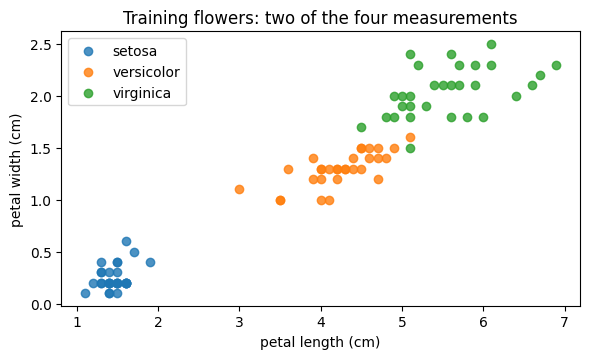

In [3]:
all_ids = np.arange(len(X))
train_val_ids, test_ids = train_test_split(all_ids, test_size=0.2, stratify=y, random_state=SEED)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25,
                                     stratify=y[train_val_ids], random_state=SEED)
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
assert set(train_ids) | set(val_ids) | set(test_ids) == set(all_ids)
for name, ids in [('Training', train_ids), ('Validation', val_ids), ('Test', test_ids)]:
    print(name, len(ids), '| counts by species:', np.bincount(y[ids], minlength=3).tolist())
fig, ax = plt.subplots(figsize=(6, 3.7))
for label, name in enumerate(class_names):
    rows = train_ids[y[train_ids] == label]
    ax.scatter(X[rows, 2], X[rows, 3], label=name, alpha=0.8)
ax.set(xlabel=feature_names[2], ylabel=feature_names[3], title='Training flowers: two of the four measurements')
ax.legend(); plt.tight_layout(); plt.show()

## Scale with training information only

Standardization subtracts each training-column mean and divides by its training-column standard deviation. A scaled value says how far a measurement sits above or below the training center in units of training spread.

`axis=0` calculates one statistic per column. We reuse these exact statistics for validation, test, and future inputs. Learning statistics from held-out rows would let their information enter preparation. Floating-point inputs can contain fractional measurements; `torch.long` targets contain class indices.

In [4]:
mean = X[train_ids].mean(axis=0)
scale = X[train_ids].std(axis=0)
assert (scale > 0).all()

def prepare(ids):
    inputs = torch.from_numpy(((X[ids] - mean) / scale).astype(np.float32))
    targets = torch.from_numpy(y[ids].copy())
    return inputs, targets

X_train, y_train = prepare(train_ids)
X_val, y_val = prepare(val_ids)
# Test transformation is deferred until the model choice is fixed.
assert X_train.shape == (90, 4) and y_train.dtype == torch.long
np.testing.assert_allclose(X_train.mean(dim=0).numpy(), np.zeros(4), atol=1e-5)
print('Training means:', np.round(mean, 3))
print('Training standard deviations:', np.round(scale, 3))
print('One training row, raw:', X[train_ids[0]])
print('The same row, scaled:', np.round(X_train[0].numpy(), 3))

Training means: [5.837 3.013 3.751 1.198]
Training standard deviations: [0.861 0.414 1.762 0.757]
One training row, raw: [6.7 3.3 5.7 2.1]
The same row, scaled: [1.002 0.692 1.106 1.192]


## Build a small network and a simpler baseline

`Linear(4, 8)` combines the measurements into eight hidden scores; ReLU keeps positive scores and replaces negative ones with zero. `Linear(8, 3)` gives one raw class score, or logit, per species. The network has sixty-seven adjustable parameters.

`CrossEntropyLoss` expects logits shaped `(batch, classes)` and integer targets shaped `(batch,)`. Softmax is unnecessary before the loss. We use it later to display probabilities.

The baseline is multinomial logistic regression: class scores come directly from the same scaled inputs without a hidden layer. Its fixed L2 regularization strength is `C=1.0`; we do not tune it on test data. Neither model is promised to win.

In [5]:
def make_model():
    return nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 3))

model = make_model()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=15, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))
baseline = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
baseline.fit(X_train.numpy(), y_train.numpy())
assert baseline.n_iter_.max() < 1000
assert model(X_train[:5]).shape == (5, 3)
assert sum(p.numel() for p in model.parameters()) == 67
print(model)
print('Neural-network parameters:', sum(p.numel() for p in model.parameters()))
print('Baseline coefficients and intercepts:', baseline.coef_.size + baseline.intercept_.size)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)
Neural-network parameters: 67
Baseline coefficients and intercepts: 15


## Train on batches and select with validation loss

Each epoch visits six training batches. Clear old gradients, predict, measure cross-entropy, run backward, then update. `backward()` calculates gradients; `step()` changes parameters. Adam is created once so it retains its history.

After every epoch, evaluate complete groups using one fixed model state. `eval()` selects evaluation behavior; `no_grad()` separately avoids recording a gradient graph. Deep-copy the best validation state, including the initial state as a candidate. We finish the fixed budget and restore the best checkpoint; test data is not involved.

Updates: 1200; selected epoch: 55; validation loss: 0.171591
Selected validation accuracy: 93.3%


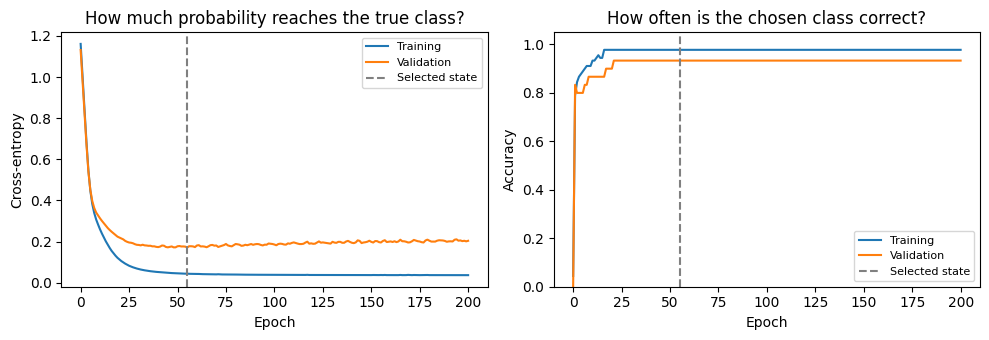

In [6]:
def evaluate(network, inputs, targets):
    network.eval()
    with torch.no_grad():
        logits = network(inputs)
        return (loss_fn(logits, targets).item(),
                (logits.argmax(dim=1) == targets).float().mean().item())

history = []
best_val_loss, best_epoch, best_state = float('inf'), None, None
updates = 0
for epoch in range(201):
    train_loss, train_accuracy = evaluate(model, X_train, y_train)
    val_loss, val_accuracy = evaluate(model, X_val, y_val)
    history.append((train_loss, val_loss, train_accuracy, val_accuracy))
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch < 200:
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(batch_x), batch_y)
            assert torch.isfinite(loss)
            loss.backward()
            optimizer.step()
            updates += 1

history = np.array(history)
assert np.isfinite(history).all() and updates == 1200
model.load_state_dict(best_state)
model.eval()
np.testing.assert_allclose(evaluate(model, X_val, y_val)[0], best_val_loss, rtol=1e-6)
print(f'Updates: {updates}; selected epoch: {best_epoch}; validation loss: {best_val_loss:.6f}')
print(f'Selected validation accuracy: {evaluate(model, X_val, y_val)[1]:.1%}')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history[:, 0], label='Training'); axes[0].plot(history[:, 1], label='Validation')
axes[0].set(ylabel='Cross-entropy', title='How much probability reaches the true class?')
axes[1].plot(history[:, 2], label='Training'); axes[1].plot(history[:, 3], label='Validation')
axes[1].set(ylabel='Accuracy', ylim=(0, 1.05), title='How often is the chosen class correct?')
for ax in axes:
    ax.axvline(best_epoch, color='gray', linestyle='--', label='Selected state')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Evaluate the fixed choices on test flowers

The checkpoint and baseline settings are now fixed. Transform test measurements using the training statistics and evaluate both models once. Accuracy is the fraction of correct class choices. Log loss is the average minus log probability assigned to the true class; it distinguishes confident mistakes from tentative ones.

No settings change in response to this comparison. Thirty test flowers give a coarse estimate: a single changed prediction moves accuracy by about three percentage points.

In [7]:
X_test, y_test = prepare(test_ids)
with torch.no_grad():
    neural_probabilities = torch.softmax(model(X_test), dim=1).numpy()
baseline_probabilities = baseline.predict_proba(X_test.numpy())
np.testing.assert_array_equal(baseline.classes_, np.arange(3))
results = {}
for name, probabilities in [('Logistic regression', baseline_probabilities),
                             ('Neural network', neural_probabilities)]:
    np.testing.assert_allclose(probabilities.sum(axis=1), 1., atol=1e-6)
    predictions = probabilities.argmax(axis=1)
    correct = int((predictions == y_test.numpy()).sum())
    log_loss = float(-np.log(np.clip(probabilities[np.arange(len(y_test)), y_test.numpy()], 1e-12, 1.)).mean())
    results[name] = {'correct': correct, 'accuracy': correct / len(y_test), 'log_loss': log_loss}
    print(f'{name:20s}: {correct}/{len(y_test)} correct | accuracy {correct/len(y_test):.1%} | log loss {log_loss:.4f}')
assert all(np.isfinite(result['log_loss']) for result in results.values())

Logistic regression : 28/30 correct | accuracy 93.3% | log loss 0.2067
Neural network      : 28/30 correct | accuracy 93.3% | log loss 0.1403


## Look at which species get confused

A confusion matrix counts actual classes in rows and predicted classes in columns. Correct predictions lie on the diagonal. Each row here contains ten test flowers. We show both models without using the errors to retune them.

The displayed probability is a model estimate, not a guarantee of correctness. A classifier limited to these classes will still choose one for an unfamiliar plant unless a separate rejection mechanism is designed.

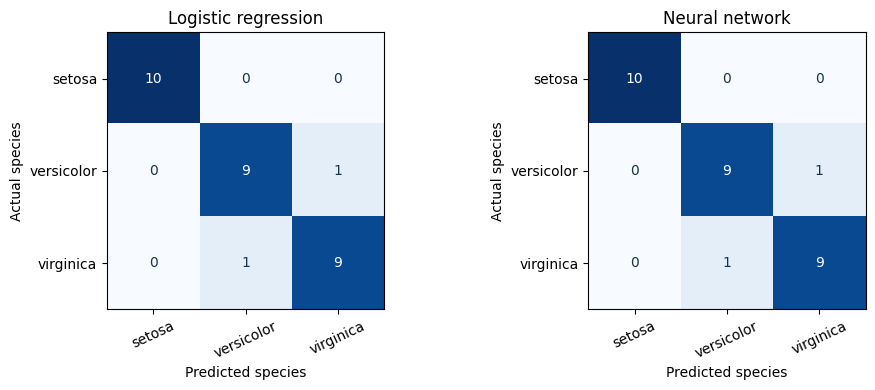

One held-out flower, measurements: [4.400000095367432, 3.0, 1.2999999523162842, 0.20000000298023224]
Actual: setosa
Predicted: setosa
Probabilities: {'setosa': 0.9999, 'versicolor': 1e-04, 'virginica': 0.0}


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, probabilities in zip(axes, ['Logistic regression', 'Neural network'],
                                  [baseline_probabilities, neural_probabilities]):
    matrix = np.zeros((3, 3), dtype=int)
    np.add.at(matrix, (y_test.numpy(), probabilities.argmax(axis=1)), 1)
    assert matrix.sum() == len(y_test)
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=10)
    for row in range(3):
        for col in range(3):
            ax.text(col, row, str(matrix[row, col]), ha='center', va='center',
                    color='white' if matrix[row, col] > 5 else '#17324d')
    ax.set(xticks=range(3), yticks=range(3), xticklabels=class_names, yticklabels=class_names,
           xlabel='Predicted species', ylabel='Actual species', title=name)
    ax.tick_params(axis='x', labelrotation=25)
plt.tight_layout(); plt.show()

row = 0
print('One held-out flower, measurements:', X[test_ids[row]].tolist())
print('Actual:', class_names[y_test[row].item()])
print('Predicted:', class_names[int(neural_probabilities[row].argmax())])
print('Probabilities:', dict(zip(class_names, np.round(neural_probabilities[row], 4))))

## Reuse the predictor with the same feature order and scaling

A prediction function should take raw centimeter measurements, validate their shape and finite values, apply the saved training transformation, and return class probabilities. The supplied values must describe the four expected measurements in the original order. Numerical checks cannot establish that a flower belongs to one of these species.

We use a training flower to demonstrate this interface so the example does not create a new test-based decision. One row still needs two-dimensional shape `(1, 4)`.

In [9]:
def predict_measurements(network, raw_rows, training_mean, training_scale):
    rows = np.asarray(raw_rows, dtype=np.float32)
    if rows.ndim != 2 or rows.shape[1] != 4:
        raise ValueError('Expected a table with four measurement columns, even for one flower.')
    if not np.isfinite(rows).all():
        raise ValueError('Measurements must be finite numbers.')
    if (rows <= 0).any():
        raise ValueError('Flower lengths and widths must be positive.')
    standardized = torch.from_numpy(((rows - training_mean) / training_scale).astype(np.float32))
    network.eval()
    with torch.no_grad():
        return torch.softmax(network(standardized), dim=1).numpy()

example_rows = X[train_ids[:1]]
example_probabilities = predict_measurements(model, example_rows, mean, scale)
assert example_probabilities.shape == (1, 3)
print('Input order:', feature_names)
print('Predicted class:', class_names[int(example_probabilities[0].argmax())])
print('Class probabilities:', np.round(example_probabilities[0], 4))

Input order: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Predicted class: virginica
Class probabilities: [1.000e-04 8.000e-04 9.992e-01]


## Save the whole prediction recipe and restore it

Weights alone are not enough: save the feature order, class names, scaling statistics, and layer sizes too. This bundle is for prediction, not exact training resumption, which would also need optimizer and random-state information.

The temporary directory removes the demonstration file automatically. We reload only the trusted file created here with `weights_only=True`, reconstruct the architecture, and verify identical probabilities. The test set is not used for this round-trip check.

In [10]:
bundle = {
    'state_dict': copy.deepcopy(model.state_dict()),
    'mean': torch.from_numpy(mean.copy()),
    'scale': torch.from_numpy(scale.copy()),
    'feature_names': feature_names,
    'class_names': class_names,
    'layer_sizes': [4, 8, 3],
}
with tempfile.TemporaryDirectory() as folder:
    checkpoint_path = Path(folder) / 'iris_classifier.pt'
    torch.save(bundle, checkpoint_path)
    restored = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    assert restored['layer_sizes'] == [4, 8, 3]
    restored_model = make_model()
    restored_model.load_state_dict(restored['state_dict'])
    restored_probabilities = predict_measurements(restored_model, example_rows,
                                                  restored['mean'].numpy(), restored['scale'].numpy())
    np.testing.assert_allclose(restored_probabilities, example_probabilities, atol=1e-7)
    assert restored['feature_names'] == feature_names and restored['class_names'] == class_names
print('Saved and restored the prediction recipe; probabilities match.')
print('Temporary checkpoint removed. All notebook checks passed.')

Saved and restored the prediction recipe; probabilities match.
Temporary checkpoint removed. All notebook checks passed.


## What this project establishes

We built a small classifier with separate data roles, training-only preprocessing, validation checkpoint selection, a simpler baseline, and a verified prediction interface. The saved results describe this single small split; neither a high score nor a high confidence value proves reliable identification in other settings.

A simple baseline may be sufficient for these measurements. The neural network earns its place only when its usefulness justifies its additional complexity. Nothing in this notebook uses the test results to redesign the models.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

scores = torch.tensor([.95, .80, .60, .40, .20, .05]).numpy()
truth = torch.tensor([1, 1, 0, 1, 0, 0]).numpy()
for threshold in [.3, .5, .7]:
    predicted = (scores >= threshold).astype(int)
    print(threshold, 'precision=', round(precision_score(truth, predicted, zero_division=0), 3),
          'recall=', round(recall_score(truth, predicted), 3),
          'F1=', round(f1_score(truth, predicted, zero_division=0), 3))
fpr, tpr, thresholds = roc_curve(truth, scores)
auc = roc_auc_score(truth, scores)
assert 0 <= auc <= 1 and len(fpr) == len(tpr) == len(thresholds)
print('ROC-AUC:', auc)

# Fit preprocessing only on the training split.
train_numeric = [[10.], [20.], [30.]]
scaler = MinMaxScaler().fit(train_numeric)
assert scaler.transform([[20.]])[0, 0] == .5
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit([['red'], ['blue']])
encoded = encoder.transform([['blue'], ['red'], ['new']])
assert encoded.shape == (3, 2) and encoded[-1].sum() == 0
print('one-hot rows:', encoded.tolist())

# Macro, micro, and support-weighted averaging differ when class support differs.
from sklearn.metrics import f1_score
multi_truth = [0, 0, 0, 1, 1, 2]
multi_pred = [0, 0, 1, 1, 0, 2]
print('F1 macro/micro/weighted:', [round(f1_score(multi_truth, multi_pred, average=mode), 3)
                                  for mode in ['macro', 'micro', 'weighted']])